# Differential gene expression across condition combinations

In this tutorial we show how to use `patpy` to run differential expression (DE)
across all pairwise contrasts of a multi-dimensional condition space with a
single function call, using any pertpy statistical model.

The wrapper `run_condition_combinations` handles:
- creating a combined condition label column
- enumerating all (or a selected subset of) observed pairwise contrasts
- running `model.compare_groups()` for each pair
- concatenating results with a `"contrast"` column

We use the **COMBAT COVID-19 cohort** (PBMC from ~140 donors) as a real-world
example, following the same pseudobulk pipeline as the
[pertpy DE tutorial](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/differential_gene_expression.html).

## Install

```bash
pip install patpy pertpy pydeseq2
# For EdgeR (requires R):
pip install rpy2
# In R: BiocManager::install("edgeR")
```

## Import packages

In [1]:
import pertpy as pt
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

import patpy
import patpy.tl.condition_utils as ptc

warnings.filterwarnings("ignore")
patpy.__version__

/lustre/groups/ml01/workspace/lucas.arnoldt/cellink_patpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.12.1'

## Load the COMBAT dataset

The dataset contains 836k cells x 20,807 genes from ~140 PBMC donors spanning
healthy volunteers (HV) and COVID-19 patients at various severity levels.

In [2]:
ADATA_PATH = "/home/icb/lucas.arnoldt/workspace/projects/patpy/COMBAT-CITESeq-DATA.h5ad"
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 836148 × 20807
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_H

## Set column names

In [3]:
sample_id_col = "scRNASeq_sample_ID"       # per-donor identifier
cell_type_key = "Annotation_major_subset"  # broad cell type labels
source_col    = "Source"                   # Covid / HV / Flu / Sepsis
outcome_col   = "Outcome"                  # 1-6 severity; 6 = healthy

## Subset to a manageable cohort

We keep only **COVID-19 patients and healthy volunteers** and sample up to
**20 donors per source** (Covid / HV) so the analysis finishes quickly and
both groups are always represented.
Remove this cell to run on the full dataset.

In [4]:
# Restrict to Covid and HV sources only
adata = adata[adata.obs[source_col].isin(["COVID_SEV", "HV"])].copy()

# Sample up to 20 donors *per source* so both Covid and HV are always present
rng = np.random.default_rng(42)
keep = []
for source, grp in adata.obs.groupby(source_col):
    donors = grp[sample_id_col].unique()
    sampled = rng.choice(donors, size=min(20, len(donors)), replace=False)
    keep.extend(sampled)

adata = adata[adata.obs[sample_id_col].isin(keep)].copy()

print(f"{adata.n_obs:,} cells | {adata.obs[sample_id_col].nunique()} donors")
adata.obs[[sample_id_col, source_col]].drop_duplicates()[source_col].value_counts()

214,842 cells | 30 donors


Source
COVID_SEV    20
HV           10
Name: count, dtype: int64

## Inspect and label the Outcome variable

`Outcome` in COMBAT is a **per-cell** numeric variable that encodes the donor's
disease severity: **1–5 = COVID patient** (1 = most severe), **6 = healthy**.
We confirm the distribution at the donor level before mapping to readable labels.

In [5]:
# Outcome is stored per cell but is constant within a donor — inspect at donor level
donor_meta = adata.obs[[sample_id_col, outcome_col, source_col]].drop_duplicates()
print(f"{donor_meta[outcome_col].value_counts().sort_index().to_string()}")
print()
print("Source breakdown:")
print(donor_meta[source_col].value_counts().to_string())

Outcome
1.0     1
2.0     5
3.0     6
4.0     8
6.0    10

Source breakdown:
Source
COVID_SEV    20
HV           10


In [6]:
# Map to readable severity labels
outcome_map = {
    1.0: "severe", 2.0: "severe", 3.0: "severe", 4.0: "severe",
    5.0: "mild",
    6.0: "healthy",
}
adata.obs["severity"] = adata.obs[outcome_col].map(outcome_map)

# Confirm both groups are present
adata.obs[[sample_id_col, source_col, "severity"]].drop_duplicates()["severity"].value_counts()

severity
severe     20
healthy    10
Name: count, dtype: int64

## Quality control

Remove donors with fewer than 100 cells.

In [7]:
adata = patpy.pp.filter_small_samples(
    adata, sample_key=sample_id_col, sample_size_threshold=100
)
print(f"{adata.obs[sample_id_col].nunique()} donors after QC filtering")

0 samples removed: 
30 donors after QC filtering


In [8]:
adata.layers["raw"] = adata.layers["raw"].todense()

## Create pseudobulk profiles

DE models require integer counts aggregated at the donor level.
We use patpy's own `Pseudobulk` class. After calling `calculate_distance_matrix()`,
the mean-aggregated expression per donor is stored in `pb.sample_representation`
(shape: `n_donors × n_genes`).

We then wrap this into an `AnnData` and swap in the raw counts from `adata.layers["raw"]`
— because the DE models need integer counts, not mean-normalised values.

In [9]:
pb = patpy.tl.Pseudobulk(
    sample_key=sample_id_col,
    cell_group_key=cell_type_key,
    layer="raw",
)
pb.prepare_anndata(adata)

# calculate_distance_matrix() populates pb.sample_representation
# (shape: n_donors x n_genes, mean-aggregated per donor)
pb.calculate_distance_matrix(aggregate="sum")
print(f"sample_representation shape: {pb.sample_representation.shape}")
print(f"donors: {len(pb.samples)}")

sample_representation shape: (30, 20807)
donors: 30


In [10]:
import anndata as ad

# Build donor-level obs from adata (severity, Source, Sex are constant per donor)
donor_obs = (
    adata.obs[[sample_id_col, "severity", source_col, "Sex"]]
    .drop_duplicates(subset=sample_id_col)
    .set_index(sample_id_col)
    .loc[list(pb.samples)]
)
"""

# Aggregate raw counts per donor (sum, integer) for DE models
raw = adata.layers["raw"]  # sparse (cells x genes)
X_counts = np.zeros((len(pb.samples), adata.n_vars), dtype=np.float32)
for i, sample in enumerate(pb.samples):
    mask = (adata.obs[sample_id_col] == sample).values  # numpy bool array
    cells = raw[mask, :]
    X_counts[i] = np.asarray(cells.sum(axis=0)).flatten()
"""
pdata = ad.AnnData(
    X=pb.sample_representation,#X_counts,
    obs=donor_obs,
    var=adata.var,
)
pdata.layers["counts"] = pdata.X.copy()
#pdata.layers["counts"] = pdata.layers["counts"].astype("int")
pdata

AnnData object with n_obs × n_vars = 30 × 20807
    obs: 'severity', 'Source', 'Sex'
    var: 'gene_ids', 'feature_types'
    layers: 'counts'

In [11]:
# Confirm condition columns are present in pdata.obs
pdata.obs[["severity", source_col, "Sex"]].drop_duplicates()

,severity,Source,Sex
scRNASeq_sample_ID,,,
S00056-Ja003E-PBCa,severe,COVID_SEV,0
H00067-Ha001E-PBGa,healthy,HV,0
S00033-Ja001E-PBCa,severe,COVID_SEV,1
H00054-Ha001E-PBGa,healthy,HV,1


## Explore axes of variation

Before fitting any DE model it is useful to understand which covariates
drive variance in the pseudobulk profiles. We run PCA and use ANOVA to
associate each PC with metadata.

This guides the choice of design formula and which contrasts are worth testing.

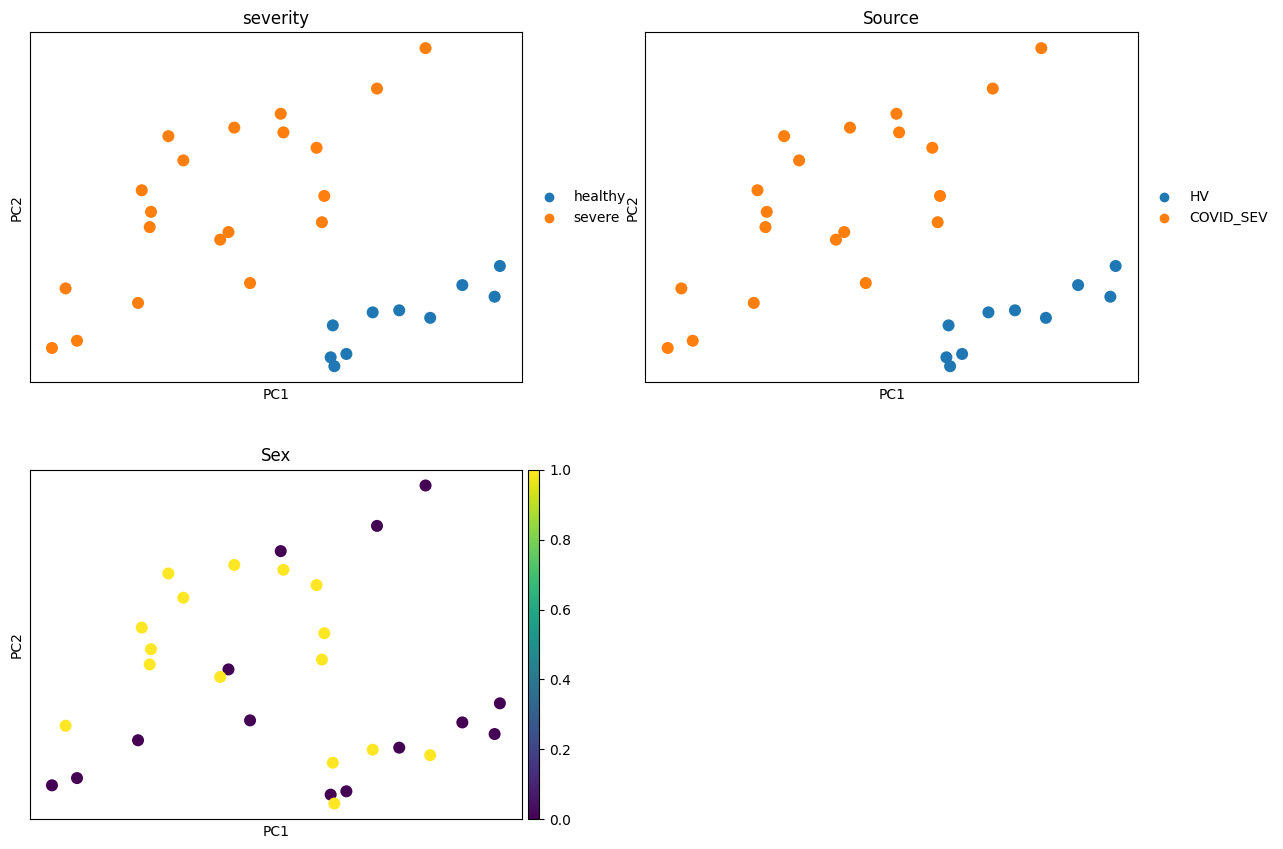

In [12]:
pdata_pca = pdata.copy()
sc.pp.normalize_total(pdata_pca, target_sum=1e4)
sc.pp.log1p(pdata_pca)
sc.pp.scale(pdata_pca, max_value=10)
sc.pp.pca(pdata_pca)

# Copy PCA embedding back to pdata for downstream ANOVA plot
pdata.obsm["X_pca"] = pdata_pca.obsm["X_pca"]

sc.pl.pca(pdata_pca, color=["severity", source_col, "Sex"], ncols=2, size=300)

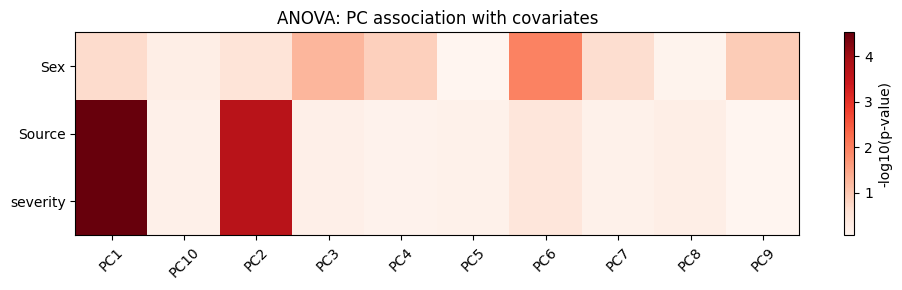

In [13]:
# ANOVA: which PCs are associated with each covariate?
# We use scipy to compute one-way ANOVA of each PC score against each categorical covariate.
from scipy import stats

n_pcs = 10
results = []
for covariate in ["severity", source_col, "Sex"]:
    groups = pdata.obs[covariate].astype(str)
    for pc in range(n_pcs):
        scores = pdata.obsm["X_pca"][:, pc]
        groups_vals = [scores[groups == g] for g in groups.unique() if len(scores[groups == g]) > 1]
        if len(groups_vals) < 2:
            continue
        f, p = stats.f_oneway(*groups_vals)
        results.append({"covariate": covariate, "PC": f"PC{pc+1}", "p_value": p, "-log10p": -np.log10(p + 1e-300)})

anova_df = pd.DataFrame(results)
pivot = anova_df.pivot(index="covariate", columns="PC", values="-log10p")

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(pivot.values, aspect="auto", cmap="Reds")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45)
ax.set_yticks(range(len(pivot.index)));  ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label="-log10(p-value)")
ax.set_title("ANOVA: PC association with covariates")
plt.tight_layout()

## Inspect the condition space

`ptc.build_condition_combinations` lists every *observed* combination of
condition axes and `ptc.build_all_pairwise_contrasts` enumerates all pairs.
This is a quick sanity check before launching any model fits.

In [14]:
condition_cols = ["severity", source_col]

combos = ptc.build_condition_combinations(pdata, condition_cols)
print(f"{len(combos)} observed condition combinations:")
combos

2 observed condition combinations:


,severity,Source,label
0,severe,COVID_SEV,severe_COVID_SEV
1,healthy,HV,healthy_HV


In [15]:
contrasts = ptc.build_all_pairwise_contrasts(pdata, condition_cols)
print(f"{len(contrasts)} pairwise contrasts:")
for c in contrasts:
    print(f"  {c['label']}")

1 pairwise contrasts:
  severe_COVID_SEV_vs_healthy_HV


## Differential expression — PyDESeq2

`run_condition_combinations` runs any pertpy model class across every observed
pairwise contrast. Failed contrasts are skipped with a warning.
All keyword arguments are forwarded to `model_cls.compare_groups()`.

In [16]:
res_deseq2 = ptc.run_condition_combinations(
    pt.tl.PyDESeq2,
    pdata,
    condition_cols=condition_cols,
    layer="counts",
)

print(f"{len(res_deseq2):,} DE results across {res_deseq2['contrast'].nunique()} contrasts")
res_deseq2.head()

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 22.38 seconds.

Fitting dispersion trend curve...
... done in 1.06 seconds.

Fitting MAP dispersions...
... done in 29.68 seconds.

Fitting LFCs...
... done in 15.46 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 252 outlier genes.

Fitting dispersions...
... done in 0.49 seconds.

Fitting MAP dispersions...
... done in 0.50 seconds.

Fitting LFCs...
... done in 0.31 seconds.

Running Wald tests...
... done in 60.64 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.396043        1.248337  1.305569  0.956163  0.338990   
NOC2L             1212.810770        0.067816  0.061259  1.107030  0.268281   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   14104.676718       -0.039824  0.107165 -0.371613  0.710181   
AB_CD224        209277.179155        0.409534  0.120223  3.406460  0.000658   
AB_c_Met         40707.871349       -0.036795  0.098071 -0.375191  0.707518   
AB_CD258_LIGHT   27915.251432        0.097523  0.116619  0.836255  0.403011   
AB_DR3_TRAMP     50528.479383       -0.093937  0.091834 -1.022906  0

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,ZNF230,117.755606,-1.386696,0.095572,-14.509435,1.055862e-47,1.685367e-43,severe_COVID_SEV_vs_healthy_HV
1,ID3,407.193037,-2.328953,0.170267,-13.678266,1.369180e-42,1.092742e-38,severe_COVID_SEV_vs_healthy_HV
2,UBE2C,584.526538,2.785062,0.205352,13.562353,6.695302e-42,3.562347e-38,severe_COVID_SEV_vs_healthy_HV
3,CDCA5,215.469175,2.666919,0.206724,12.900895,4.449011e-38,1.775378e-34,severe_COVID_SEV_vs_healthy_HV
4,IFNL1,53.722534,-2.255465,0.177897,-12.678456,7.785074e-37,2.485307e-33,severe_COVID_SEV_vs_healthy_HV


## Differential expression — EdgeR

Switch to EdgeR by changing a single argument — everything else is identical.
EdgeR requires R with the `edgeR` Bioconductor package installed.

In [17]:
res_edger = ptc.run_condition_combinations(
    pt.tl.EdgeR,
    pdata,
    condition_cols=condition_cols,
    layer="counts",
)

print(f"{len(res_edger):,} DE results across {res_edger['contrast'].nunique()} contrasts")
res_edger.head()

• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
20,807 DE results across 1 contrasts


,variable,log_fc,logCPM,F,p_value,adj_p_value,contrast
0,KIRREL3,-3.957644,-2.430068,141.738518,1.484564e-16,3.088933e-12,severe_COVID_SEV_vs_healthy_HV
1,ZNF230,-1.411199,1.200484,229.098794,4.321077e-16,4.495432e-12,severe_COVID_SEV_vs_healthy_HV
2,ID3,-2.354714,2.974807,220.264493,7.444867e-16,5.163511e-12,severe_COVID_SEV_vs_healthy_HV
3,SCARA5,-4.308078,-2.810330,118.157200,1.039509e-15,5.407268e-12,severe_COVID_SEV_vs_healthy_HV
4,ZNF217,-1.264288,4.327345,184.439553,8.619414e-15,3.586883e-11,severe_COVID_SEV_vs_healthy_HV


## Reuse settings with `ConditionComparison`

`ConditionComparison` stores the model class and default kwargs so you can
run the same setup across multiple condition axes without repeating yourself.

In [18]:
cc = ptc.ConditionComparison(pt.tl.PyDESeq2, layer="counts")
cc

ConditionComparison(PyDESeq2, layer='counts')

In [19]:
# All pairwise combinations of severity x Source
res_sev_src = cc.run(pdata, condition_cols=["severity", source_col])

# Severity alone — a simpler sanity-check
res_sev = cc.run(pdata, condition_cols=["severity"])

print("severity x Source contrasts:", res_sev_src["contrast"].unique().tolist())
print("severity-only contrasts:    ", res_sev["contrast"].unique().tolist())

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 21.61 seconds.

Fitting dispersion trend curve...
... done in 0.91 seconds.

Fitting MAP dispersions...
... done in 29.49 seconds.

Fitting LFCs...
... done in 14.72 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 252 outlier genes.

Fitting dispersions...
... done in 0.40 seconds.

Fitting MAP dispersions...
... done in 0.47 seconds.

Fitting LFCs...
... done in 0.28 seconds.

Running Wald tests...
... done in 53.14 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.396043        1.248337  1.305569  0.956163  0.338990   
NOC2L             1212.810770        0.067816  0.061259  1.107030  0.268281   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   14104.676718       -0.039824  0.107165 -0.371613  0.710181   
AB_CD224        209277.179155        0.409534  0.120223  3.406460  0.000658   
AB_c_Met         40707.871349       -0.036795  0.098071 -0.375191  0.707518   
AB_CD258_LIGHT   27915.251432        0.097523  0.116619  0.836255  0.403011   
AB_DR3_TRAMP     50528.479383       -0.093937  0.091834 -1.022906  0

Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 20.90 seconds.

Fitting dispersion trend curve...
... done in 0.82 seconds.

Fitting MAP dispersions...
... done in 28.25 seconds.

Fitting LFCs...
... done in 15.36 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 252 outlier genes.

Fitting dispersions...
... done in 0.43 seconds.

Fitting MAP dispersions...
... done in 0.48 seconds.

Fitting LFCs...
... done in 0.27 seconds.

Running Wald tests...
... done in 53.37 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.396043        1.248337  1.305569  0.956163  0.338990   
NOC2L             1212.810770        0.067816  0.061259  1.107030  0.268281   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   14104.676718       -0.039824  0.107165 -0.371613  0.710181   
AB_CD224        209277.179155        0.409534  0.120223  3.406460  0.000658   
AB_c_Met         40707.871349       -0.036795  0.098071 -0.375191  0.707518   
AB_CD258_LIGHT   27915.251432        0.097523  0.116619  0.836255  0.403011   
AB_DR3_TRAMP     50528.479383       -0.093937  0.091834 -1.022906  0

## Restrict to biologically motivated contrasts

Pass `subset_contrasts` to run only the comparisons you care about — here,
only contrasts that involve the healthy reference group.

In [20]:
all_contrasts = ptc.build_all_pairwise_contrasts(pdata, condition_cols)

vs_healthy = [c for c in all_contrasts if "healthy" in c["group"] or "healthy" in c["baseline"]]
print("Contrasts vs healthy:", [c["label"] for c in vs_healthy])

res_vs_healthy = ptc.run_condition_combinations(
    pt.tl.PyDESeq2,
    pdata,
    condition_cols=condition_cols,
    layer="counts",
    subset_contrasts=vs_healthy,
)
res_vs_healthy["contrast"].unique()

Contrasts vs healthy: ['severe_COVID_SEV_vs_healthy_HV']
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 22.28 seconds.

Fitting dispersion trend curve...
... done in 0.95 seconds.

Fitting MAP dispersions...
... done in 28.94 seconds.

Fitting LFCs...
... done in 15.36 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 252 outlier genes.

Fitting dispersions...
... done in 0.45 seconds.

Fitting MAP dispersions...
... done in 0.54 seconds.

Fitting LFCs...
... done in 0.26 seconds.

Running Wald tests...
... done in 53.26 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.396043        1.248337  1.305569  0.956163  0.338990   
NOC2L             1212.810770        0.067816  0.061259  1.107030  0.268281   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   14104.676718       -0.039824  0.107165 -0.371613  0.710181   
AB_CD224        209277.179155        0.409534  0.120223  3.406460  0.000658   
AB_c_Met         40707.871349       -0.036795  0.098071 -0.375191  0.707518   
AB_CD258_LIGHT   27915.251432        0.097523  0.116619  0.836255  0.403011   
AB_DR3_TRAMP     50528.479383       -0.093937  0.091834 -1.022906  0

array(['severe_COVID_SEV_vs_healthy_HV'], dtype=object)

## Inspect and visualise results

The output of `run_condition_combinations` is a tidy DataFrame with a
`"contrast"` column that you can filter, pivot, and plot directly.

In [21]:
# Number of significant genes per contrast (FDR < 0.05)
sig = res_deseq2[res_deseq2["adj_p_value"] < 0.05]
n_sig = (
    sig.groupby("contrast")["variable"]
    .count()
    .rename("n_sig_genes")
    .sort_values(ascending=False)
)
print(n_sig.to_string())

contrast
severe_COVID_SEV_vs_healthy_HV    6669


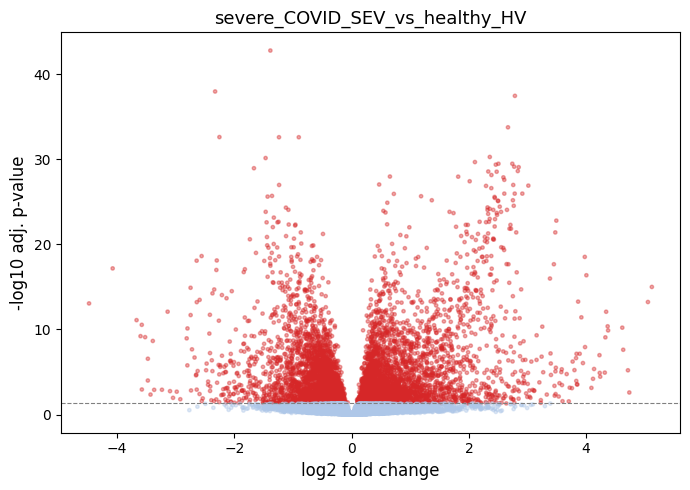

In [22]:
# Volcano plot for the contrast with the most DE genes
top_contrast = n_sig.index[0]
df_plot = res_deseq2[res_deseq2["contrast"] == top_contrast].copy()
df_plot["-log10_padj"] = -np.log10(df_plot["adj_p_value"].clip(lower=1e-300))
colors = df_plot["adj_p_value"].lt(0.05).map({True: "#d62728", False: "#aec7e8"})

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_plot["log_fc"], df_plot["-log10_padj"], s=6, alpha=0.4, c=colors)
ax.axhline(-np.log10(0.05), color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("log2 fold change", fontsize=12)
ax.set_ylabel("-log10 adj. p-value", fontsize=12)
ax.set_title(top_contrast, fontsize=13)
plt.tight_layout()

In [23]:
# Top DE genes across all contrasts (FDR < 0.05, ranked by |log2FC|)
(
    sig
    .assign(abs_lfc=sig["log_fc"].abs())
    .sort_values("abs_lfc", ascending=False)
    [["variable", "log_fc", "adj_p_value", "contrast"]]
    .drop_duplicates(subset="variable")
    .head(20)
)

,variable,log_fc,adj_p_value,contrast
263,RBP4,5.121099,1.016251e-15,severe_COVID_SEV_vs_healthy_HV
365,IFI27,5.054169,6.002726e-14,severe_COVID_SEV_vs_healthy_HV
4040,THRSP,4.736382,2.571643e-03,severe_COVID_SEV_vs_healthy_HV
1958,IGHV1-12,4.713332,6.340871e-06,severe_COVID_SEV_vs_healthy_HV
1088,IGKV3D-11,4.632542,2.445816e-08,severe_COVID_SEV_vs_healthy_HV
619,KCTD14,4.616651,6.181992e-11,severe_COVID_SEV_vs_healthy_HV
374,SCARA5,-4.479556,8.786279e-14,severe_COVID_SEV_vs_healthy_HV
668,IGHV3-49,4.374704,1.305727e-10,severe_COVID_SEV_vs_healthy_HV
604,METTL7B,4.366874,4.300232e-11,severe_COVID_SEV_vs_healthy_HV
440,ADAMTS2,4.341329,8.362932e-13,severe_COVID_SEV_vs_healthy_HV
